In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình giao diện đẹp
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. Load dữ liệu
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Chọn User mẫu (Thống nhất user 8792009665 với cả nhóm)
user_id = 8792009665
df_user = df[df['Id'] == user_id].copy().sort_values('Timestamp').set_index('Timestamp')

# 3. Feature Engineering: Tách ngày, giờ, thứ
df_user['Hour'] = df_user.index.hour
df_user['DayOfWeek'] = df_user.index.day_name()
# Tạo cột phân loại Cuối tuần vs Ngày thường
df_user['IsWeekend'] = df_user.index.dayofweek.map(lambda x: 'Weekend' if x >= 5 else 'Weekday')

print("Đã tạo xong các biến thời gian (Time Features).")
df_user[['Heart_Rate', 'Hour', 'DayOfWeek', 'IsWeekend']].head()

Đã tạo xong các biến thời gian (Time Features).


,Heart_Rate,Hour,DayOfWeek,IsWeekend
Timestamp,,,,
2016-04-01 00:00:00,81.000000,0,Friday,Weekday
2016-04-01 00:01:00,82.714286,0,Friday,Weekday
2016-04-01 00:02:00,80.833333,0,Friday,Weekday
2016-04-01 00:03:00,80.000000,0,Friday,Weekday
2016-04-01 00:04:00,82.333333,0,Friday,Weekday


C:\Users\Admin\AppData\Local\Temp\ipykernel_26056\4143919134.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Heart_Rate', data=df_user, palette="viridis")


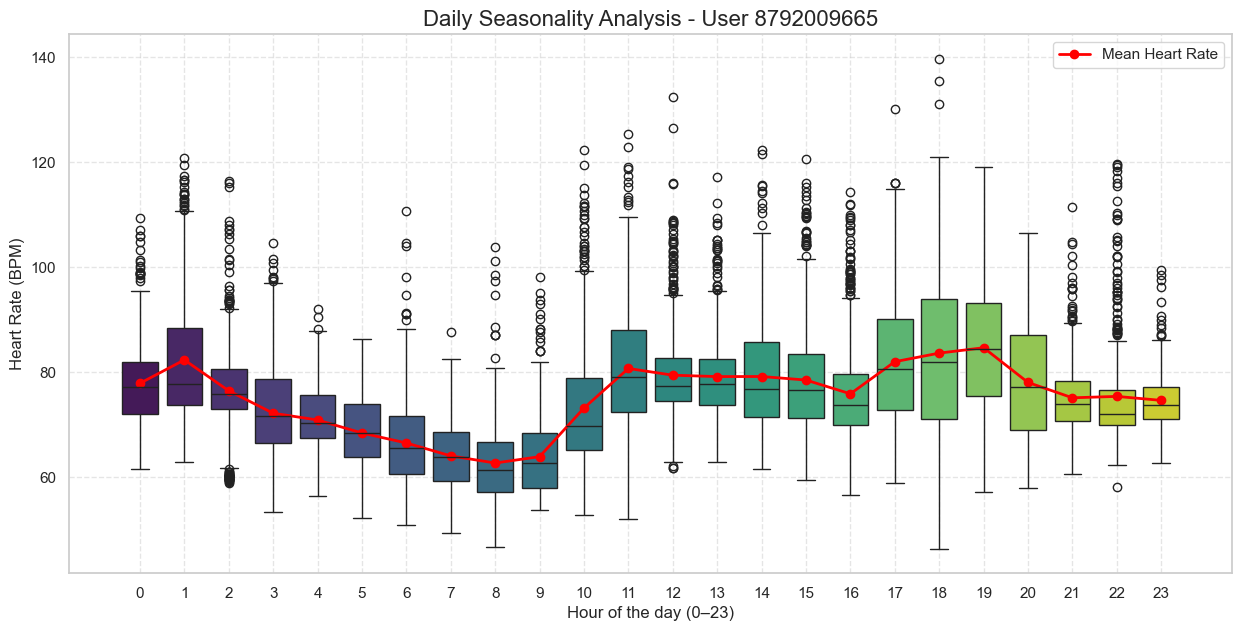

In [3]:
plt.figure(figsize=(15, 7))

# Vẽ Boxplot theo giờ
# Boxplot cho thấy: Trung vị (vạch giữa), 50% dữ liệu tập trung ở đâu (cái hộp), và Outlier (chấm đen)
sns.boxplot(x='Hour', y='Heart_Rate', data=df_user, palette="viridis")

# Vẽ đường trung bình đè lên để thấy rõ xu hướng
hourly_mean = df_user.groupby('Hour')['Heart_Rate'].mean()
plt.plot(hourly_mean.index, hourly_mean.values, color='red', linewidth=2, marker='o', label='Mean Heart Rate')

plt.title(f'Daily Seasonality Analysis - User {user_id}', fontsize=16)
plt.xlabel('Hour of the day (0–23)', fontsize=12)
plt.ylabel('Heart Rate (BPM)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_26056\3642513599.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='IsWeekend', y='Heart_Rate', data=df_user,


Nhịp tim trung bình:
IsWeekend
Weekday    72.979014
Weekend    79.061563
Name: Heart_Rate, dtype: float64


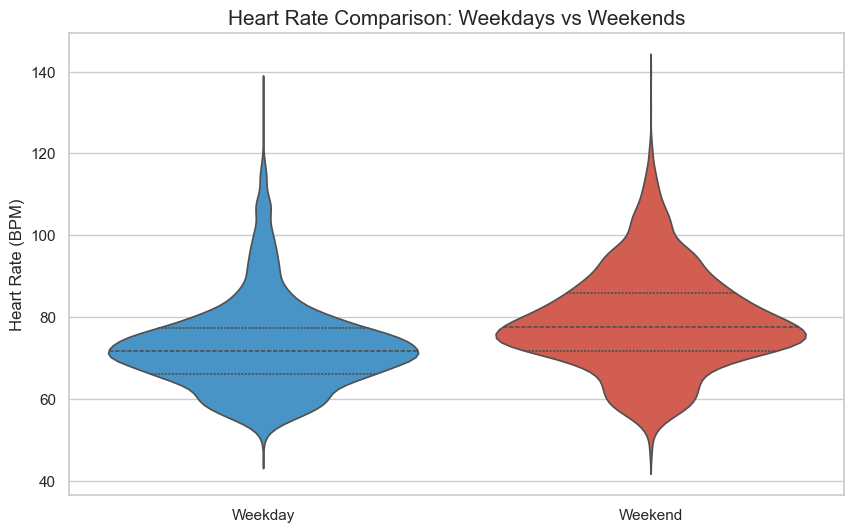

In [4]:
plt.figure(figsize=(10, 6))

# Vẽ Violin Plot (Đẹp hơn Boxplot vì thấy được mật độ phân phối)
sns.violinplot(x='IsWeekend', y='Heart_Rate', data=df_user, 
               palette={"Weekday": "#3498db", "Weekend": "#e74c3c"}, 
               inner='quartile') # inner='quartile' vẽ các đường phân vị bên trong

# Tính trung bình để so sánh cụ thể
mean_vals = df_user.groupby('IsWeekend')['Heart_Rate'].mean()
print("Nhịp tim trung bình:")
print(mean_vals)

plt.title('Heart Rate Comparison: Weekdays vs Weekends', fontsize=15)
plt.xlabel('')
plt.ylabel('Heart Rate (BPM)')

plt.show()